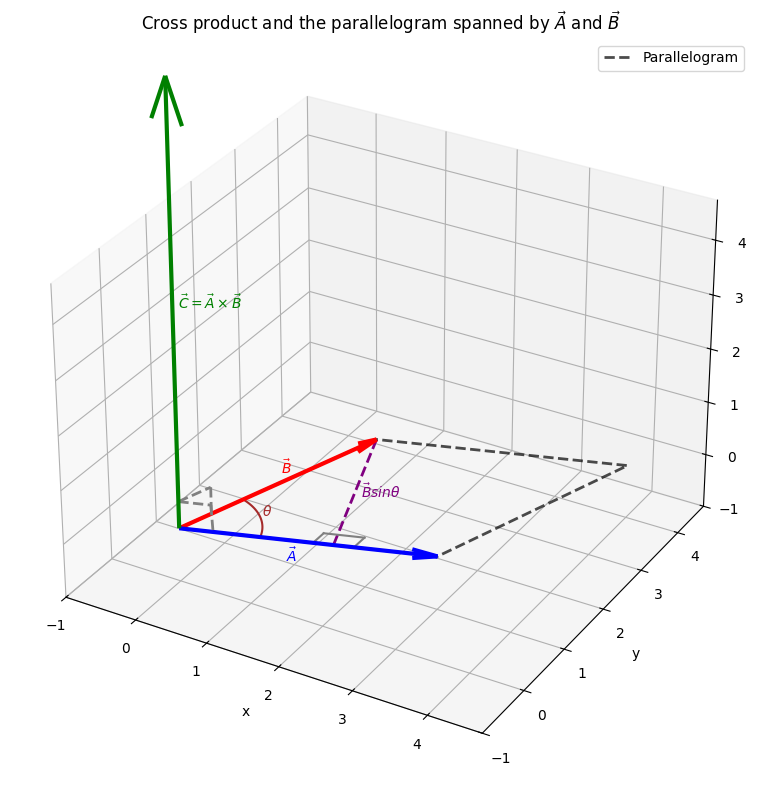

Vector A: [3 1 0]
Vector B: [1 3 0]
A × B: [0 0 8]
Area of the parallelogram: 8.000
|C| = |A × B| = |A||B|sinθ = 8.000 equals the parallelogram area


In [107]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from math import acos

vec_a, vec_b = np.array([3, 1, 0]), np.array([1, 3, 0])
vec_c = np.cross(vec_a, vec_b)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

origin = [0, 0, 0]

ax.quiver(*origin, *vec_a, color='blue', arrow_length_ratio=0.1, linewidth=3)
ax.text((vec_a/2)[0], (vec_a/2)[1]-0.5, (vec_a/2)[2], r'$\vec{A}$', color="blue")
ax.quiver(*origin, *vec_b, color='red', arrow_length_ratio=0.1, linewidth=3)
ax.text((vec_b/2)[0]-0.1, (vec_b/2)[1]+0.2, (vec_b/2)[2], r'$\vec{B}$', color="red")
ax.quiver(*origin, *vec_c, color='green', arrow_length_ratio=0.1, linewidth=3)
ax.text((vec_c/2)[0]+0.05, (vec_c/2)[1]+0.05, (vec_c/2)[2], r'$\vec{C}=\vec{A}\times \vec{B}$', color="green")

# Perpendicular to A
hund = vec_a * np.dot(vec_a, vec_b) / np.dot(vec_a, vec_a)
ax.plot([vec_b[0], hund[0]], [vec_b[1], hund[1]], [vec_b[2], hund[2]], 'purple', linewidth=2, linestyle='--')
k, dir = 0.25, vec_a/np.linalg.norm(vec_a)
ax.plot([hund[0] - k*dir[0], hund[0]+k*dir[0]], [hund[1] - k*dir[1]+k, hund[1] + k*dir[1]+k], [hund[2]]*2, 'gray')
ax.plot([hund[0] - k*dir[0], hund[0] - k*dir[0]], [hund[1] - k*dir[1]+k, hund[1] - k*dir[1]], [hund[2]]*2, 'gray')
ax.plot([hund[0] + k*dir[0], hund[0] + k*dir[0]], [hund[1] + k*dir[1]+k, hund[1] + k*dir[1]], [hund[2]]*2, 'gray')
ax.text((vec_b[0] + hund[0])/2+0.13, (vec_b[1] + hund[1])/2-0.1, (vec_b[2] + hund[2])/2, r'$\vec{B} sin\theta$', color="purple")

# Perpendicularity of C to A and B
ax.plot([origin[0], vec_b[0]*0.5/np.linalg.norm(vec_b)], 
        [origin[1], vec_b[1]*0.5/np.linalg.norm(vec_b)], 
        [origin[2]+0.5, origin[2]+0.5], 
        'gray', linewidth=2, linestyle='--')
ax.plot([vec_b[0]*0.5/np.linalg.norm(vec_b), vec_b[0]*0.5/np.linalg.norm(vec_b)], 
        [vec_b[1]*0.5/np.linalg.norm(vec_b), vec_b[1]*0.5/np.linalg.norm(vec_b)], 
        [origin[2]+0.5, origin[2]], 
        'gray', linewidth=2, linestyle='--')
ax.plot([origin[0], vec_a[0]*0.4/np.linalg.norm(vec_a)], 
        [origin[1], vec_a[1]*0.4/np.linalg.norm(vec_a)], 
        [origin[2]+0.5, origin[2]+0.5], 
        'gray', linewidth=2, linestyle='--')
ax.plot([vec_a[0]*0.4/np.linalg.norm(vec_a), vec_a[0]*0.4/np.linalg.norm(vec_a)], 
        [vec_a[1]*0.4/np.linalg.norm(vec_a), vec_a[1]*0.5/np.linalg.norm(vec_a)], 
        [origin[2]+0.5, origin[2]], 
        'gray', linewidth=2, linestyle='--', zorder=10)

# Angle theta
vec_axis = np.array([1, 0, 0])
arc_theta = np.linspace(acos(np.dot(vec_a, vec_axis)/(np.linalg.norm(vec_a)*np.linalg.norm(vec_axis))), acos(np.dot(vec_axis, vec_b)/(np.linalg.norm(vec_axis)*np.linalg.norm(vec_b))))
arc_x = np.cos(arc_theta)
arc_y = np.sin(arc_theta)
arc_z = np.zeros(50)
ax.plot(arc_x, arc_y, arc_z, "brown")
ax.text(arc_x[len(arc_x)//2]+0.02, arc_y[len(arc_x)//2]+0.02, 0, r'$\theta$', color="brown")

# Parallelogram spanned by vectors A and B
p  = [origin, vec_a, vec_a + vec_b, vec_b]
ax.plot([p[0][0], p[1][0], p[2][0], p[3][0], p[0][0]], 
        [p[0][1], p[1][1], p[2][1], p[3][1], p[0][1]], 
        [p[0][2], p[1][2], p[2][2], p[3][2], p[0][2]], 
        'k--', alpha=0.7, linewidth=2, label='Parallelogram')

mrange = np.array([ax.get_xlim(), ax.get_ylim(), ax.get_zlim()]).max() * 1.1
ax.set_xlim([-1, mrange])
ax.set_ylim([-1, mrange])
ax.set_zlim([-1, mrange])

# The axes
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'Cross product and the parallelogram spanned by $\vec{A}$ and $\vec{B}$')

ax.legend()

# Add text annotations showing perpendicularity
dot_a_cross = np.dot(vec_a, vec_c)
dot_b_cross = np.dot(vec_b, vec_c)

plt.tight_layout()
plt.show()

print(f"Vector A: {vec_a}")
print(f"Vector B: {vec_b}")
print(f"A × B: {vec_c}")
print(f"Area of the parallelogram: {(area := np.linalg.norm(vec_c)):.3f}")
print(f"|C| = |A × B| = |A||B|sinθ = {area:.3f} equals the parallelogram area")